### BSAN 6070_Spring2026_ML_Final_Project
# ✈️ Flight Delay Prediction

**Predictive Question:** Can we predict whether a U.S. domestic flight will arrive 15 minutes or more late using airline, route, date, schedule, and departure-related information from 2018, 2019, 2021, and 2022?

**Target Variable:** `ArrDel15` (1 = delayed ≥15 min, 0 = on time)

## Notebook outline
* Feature Selection: process, rationale, methodology
* Preprocessing decisions (encoding, scaling, leakage guard)
* Train/Test split support
* Model Assumption Validation
* Individual Model: XGBoost / Gradient Boosting
* Feature Importance & Explainability
* Hyperparameter tuning
* Deployment


**Setup & Imports**

In [1]:
# Install any extra libraries not in Colab by default
!pip install xgboost shap imbalanced-learn --quiet

In [16]:
!pip install gdown --quiet


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
import os, json

# Scikit-learn
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler

from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    roc_curve, precision_recall_curve, f1_score, accuracy_score)

from sklearn.feature_selection import SelectFromModel, mutual_info_classif
from sklearn.inspection import permutation_importance

# Models
from xgboost import XGBClassifier
from sklearn.ensemble import GradientBoostingClassifier

# Explainability
import shap

# Class imbalance
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

# Model persistence
import joblib

print("All imports successful ")
print(f"Pandas: {pd.__version__} | NumPy: {np.__version__}")


All imports successful 
Pandas: 3.0.2 | NumPy: 2.4.3


**Exploratory Data Analysis ---**

Direct import of dataset from kaggle using API

Using parquet; it's compressed and loads significantly faster

Loading only the columns actually needed 

**LOAD FULL DATASET INTO DATAFRAME**

Dataset was foung on kaggle; https://www.kaggle.com/datasets/robikscube/flight-delay-dataset-20182022
Steps taken to laod the dataset
1. A direct import of dataset from kaggle using API for the years needed in parquet format
2. then loaded only the columns actually need into google drive
   

Now call for dataset into dataframe from google drive

In [19]:
# Pull from shared folder from Google Drive "Anyone with the link can view"
import gdown


FILE_ID = "1Ja6U_fclo7Vg8FkXS0wCaDSz6W-z6iEJ"

# Public Google Drive file — accessible to anyone with the link
gdown.download(
    f"https://drive.google.com/uc?id={FILE_ID}",
    "cleaned_flights.parquet",
    quiet=False)

dff = pd.read_parquet("cleaned_flights.parquet")
print(f"Loaded: {dff.shape[0]:,} rows, {dff.shape[1]} columns")
dff.head(3)

Downloading...
From (original): https://drive.google.com/uc?id=1Ja6U_fclo7Vg8FkXS0wCaDSz6W-z6iEJ
From (redirected): https://drive.google.com/uc?id=1Ja6U_fclo7Vg8FkXS0wCaDSz6W-z6iEJ&confirm=t&uuid=5b08b858-6216-4ad8-a1ff-2d0e7a63fbb8
To: C:\Users\pdans\Desktop\prince_danso_BSAN_6070_ML\Final_Project_V2\cleaned_flights.parquet
100%|███████████████████████████████████████████████████████████████████████████████| 131M/131M [00:04<00:00, 29.4MB/s]


Loaded: 9,668,554 rows, 17 columns


,FlightDate,Year,Quarter,Month,DayofMonth,DayOfWeek,Marketing_Airline_Network,Operating_Airline,Origin,Dest,Distance,DistanceGroup,CRSDepTime,CRSArrTime,CRSElapsedTime,DepTimeBlk,ArrDel15
0,2021-04-15,2021,2,4,15,4,WN,WN,PVD,TPA,1136.0,5,1155,1500,185.0,1100-1159,0.0
1,2021-09-29,2021,3,9,29,3,F9,F9,PHL,DEN,1558.0,7,2006,2225,259.0,2000-2059,0.0
2,2018-08-01,2018,3,8,1,3,WN,WN,AUS,ELP,528.0,3,540,605,85.0,0001-0559,0.0


In [ ]:
# load dataset for all years: 2018, 2019, 2021, and 2022, except2020

# dff = pd.read_parquet(r"cleaned_flights.parquet")
# dff.head()


**Inspect the top 20 Airport in the dataset**

In [20]:
# As a DataFrame with frequency count
origin_counts = dff['Origin'].value_counts().rename('departures')
dest_counts   = dff['Dest'].value_counts().rename('arrivals')

airport_df = pd.DataFrame({
    'departures': origin_counts,
    'arrivals'  : dest_counts
}).fillna(0).astype(int)

airport_df['total_flights'] = airport_df['departures'] + airport_df['arrivals']
airport_df = airport_df.sort_values('total_flights', ascending=False).reset_index()
airport_df.columns = ['Airport', 'Departures', 'Arrivals', 'Total_Flights']

print(f"Total unique airports: {len(airport_df)}")
print(f"\nTop 20 busiest:")
print(airport_df.head(20).to_string(index=False))

Total unique airports: 388

Top 20 busiest:
Airport  Departures  Arrivals  Total_Flights
    ORD      460634    459288         919922
    ATL      446389    446718         893107
    DEN      385632    386581         772213
    DFW      351603    352139         703742
    CLT      288821    288906         577727
    LAX      287436    286649         574085
    SEA      236141    237384         473525
    IAH      233179    234068         467247
    PHX      221937    221080         443017
    LAS      220496    220856         441352
    SFO      202468    203209         405677
    EWR      200304    199813         400117
    DTW      192378    192538         384916
    MCO      191514    191232         382746
    LGA      183416    183734         367150
    MSP      177446    177746         355192
    BOS      174731    174378         349109
    PHL      160666    161327         321993
    DCA      159811    159889         319700
    JFK      149789    150069         299858


**Concentrate on Top 6 Busiest US Airports**

In [21]:
# Based on flight volume in dataset: ORD, ATL, DEN, DFW, CLT. LAX

TOP6_AIRPORTS = ['ORD', 'ATL', 'DEN', 'DFW', 'CLT', 'LAX']

# Keep flights where BOTH origin AND destination are in the top 5
df = dff[
    (dff['Origin'].isin(TOP6_AIRPORTS)) |
    (dff['Dest'].isin(TOP6_AIRPORTS))].copy().reset_index(drop=True)

print(f"Full dataset  : {dff.shape[0]:,} rows")
print(f"Top 6 slice   : {df.shape[0]:,} rows")
print(f"Coverage      : {len(df)/len(dff)*100:.1f}% of full dataset")
print(f"\nRows by year:")
print(df['Year'].value_counts().sort_index())
print(f"\nRoute counts (Origin → Dest):")
print(df.groupby(['Origin', 'Dest']).size().unstack(fill_value=0)[TOP6_AIRPORTS].loc[TOP6_AIRPORTS])



Full dataset  : 9,668,554 rows
Top 6 slice   : 4,223,429 rows
Coverage      : 43.7% of full dataset

Rows by year:
Year
2018     907050
2019    1443300
2021    1178477
2022     694602
Name: count, dtype: int64

Route counts (Origin → Dest):
Dest     ORD   ATL    DEN   DFW   CLT    LAX
Origin                                      
ORD        0  8942   8875  8434  5927   9309
ATL     8852     0   7733  7616  6998   7227
DEN     8969  7733      0  7346  3849  10313
DFW     8457  7748   7608     0  4337   8633
CLT     5890  6951   3887  4272     0   2855
LAX     9297  7162  10635  8718  2794      0


>ORD; O'Hare International Airport - Chicago, Illinois

>ATL; Hartsfield-Jackson Atlanta International Airport - Atlanta, Georgia

>DEN; Denver International Airport - Denver, Colorado

>DFW; Dallas/Fort Worth International Airport - Dallas, Texas

>CLT; Charlotte Douglas International Airport - Charlotte, North Carolina

>LAX; Los Angeles International Airport - Los Angeles, California

**Descriptive stats**

**Data Quality Analysis (DQA)**

**Check DataFrame's data types**

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4223429 entries, 0 to 4223428
Data columns (total 17 columns):
 #   Column                     Dtype         
---  ------                     -----         
 0   FlightDate                 datetime64[us]
 1   Year                       int64         
 2   Quarter                    int64         
 3   Month                      int64         
 4   DayofMonth                 int64         
 5   DayOfWeek                  int64         
 6   Marketing_Airline_Network  str           
 7   Operating_Airline          str           
 8   Origin                     str           
 9   Dest                       str           
 10  Distance                   float64       
 11  DistanceGroup              int64         
 12  CRSDepTime                 int64         
 13  CRSArrTime                 int64         
 14  CRSElapsedTime             float64       
 15  DepTimeBlk                 str           
 16  ArrDel15                   float64       
dtype

**calculate basic statistics for a numeric column**

In [8]:
df.describe().T

,count,mean,min,25%,50%,75%,max,std
FlightDate,4223429,2020-05-01 20:45:47.863502,2018-01-01 00:00:00,2019-02-11 00:00:00,2019-10-31 00:00:00,2021-09-17 00:00:00,2022-07-31 00:00:00,NaN
Year,4223429.0,2019.836692,2018.0,2019.0,2019.0,2021.0,2022.0,1.452936
Quarter,4223429.0,2.503366,1.0,2.0,2.0,3.0,4.0,1.098439
Month,4223429.0,6.493957,1.0,4.0,6.0,9.0,12.0,3.384708
DayofMonth,4223429.0,15.751804,1.0,8.0,16.0,23.0,31.0,8.772896
DayOfWeek,4223429.0,3.971506,1.0,2.0,4.0,6.0,7.0,2.000492
Distance,4223429.0,770.81003,67.0,360.0,621.0,967.0,4678.0,570.044909
DistanceGroup,4223429.0,3.553034,1.0,2.0,3.0,4.0,11.0,2.224856
CRSDepTime,4223429.0,1324.462841,1.0,915.0,1317.0,1730.0,2359.0,486.163835
CRSArrTime,4223429.0,1484.988048,1.0,1105.0,1512.0,1914.0,2400.0,510.467578


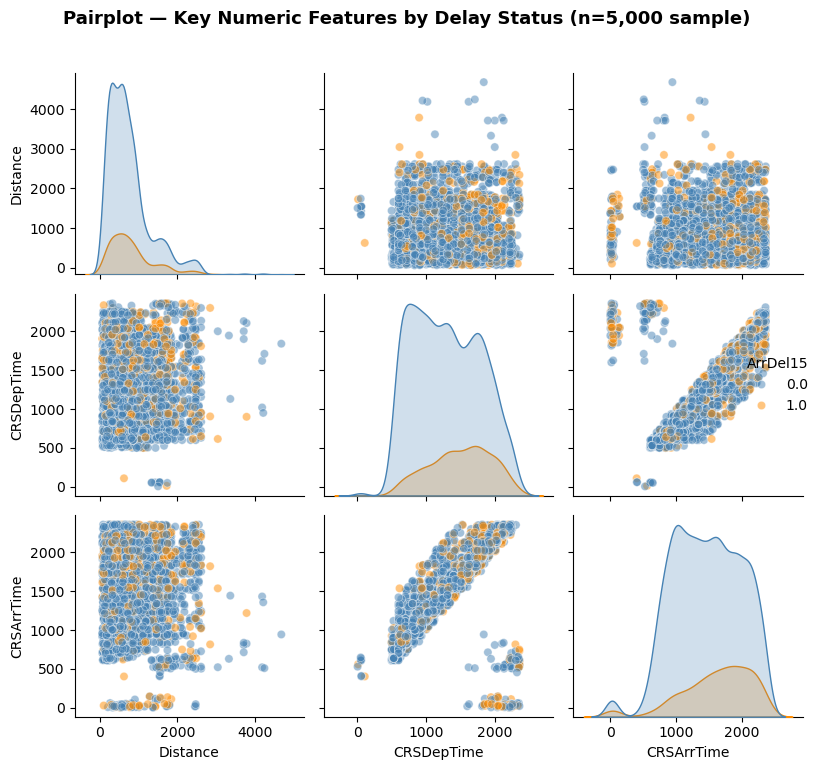

In [23]:
# Sample for pairplot — 4M rows is too large to render
df_sample = df.sample(n=5000, random_state=42)

sns.pairplot(df_sample,
             vars=['Distance', 'CRSDepTime', 'CRSArrTime'],
             hue='ArrDel15',
             palette={0: 'steelblue', 1: 'darkorange'},
             plot_kws={'alpha': 0.5},
             diag_kind='kde')

plt.suptitle('Pairplot — Key Numeric Features by Delay Status (n=5,000 sample)',
             y=1.02, fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('pairplot.png', dpi=150, bbox_inches='tight')
plt.show()


Countplot for most meaningful categorical combination, delay status by airline

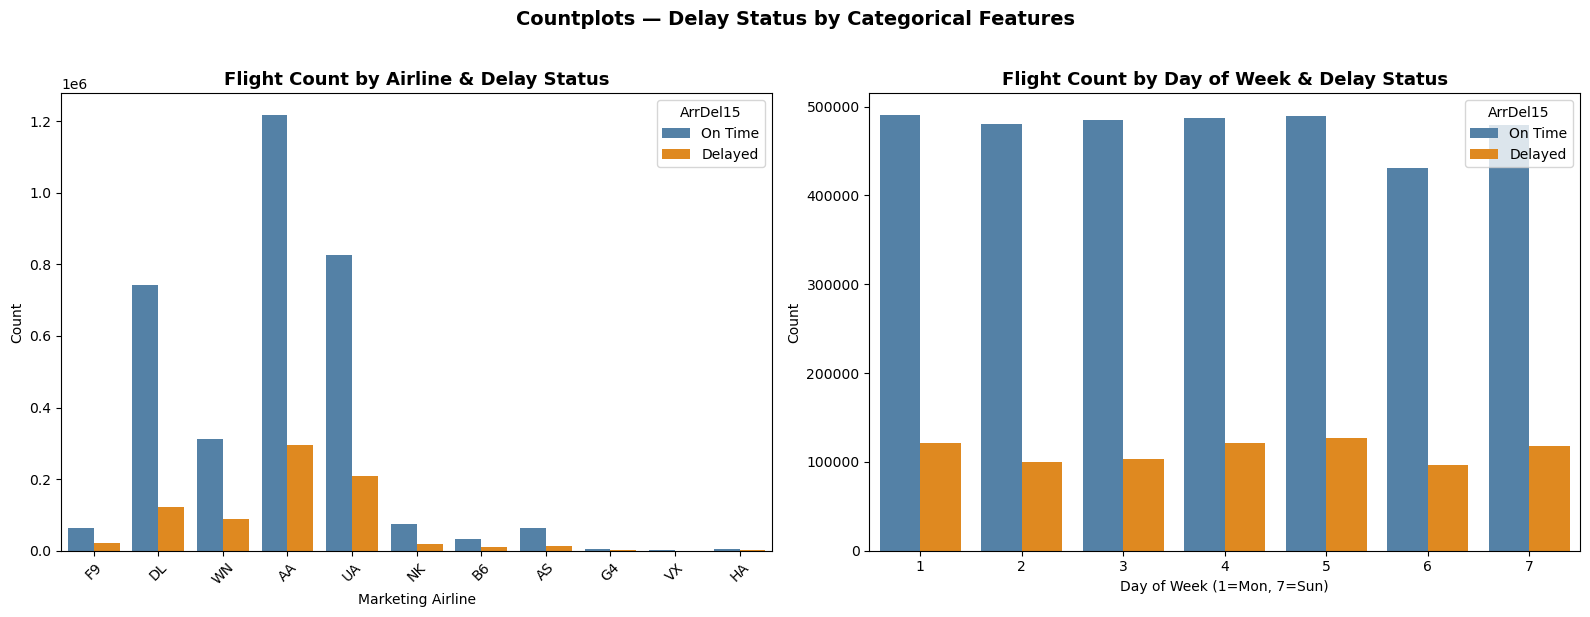

In [24]:
# Countplot — ArrDel15 count by Marketing Airline
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Delay count by airline
sns.countplot(x='Marketing_Airline_Network', hue='ArrDel15',
              data=df,
              palette={0: 'steelblue', 1: 'darkorange'},
              ax=axes[0])
axes[0].set_title('Flight Count by Airline & Delay Status',
                  fontsize=13, fontweight='bold')
axes[0].set_xlabel('Marketing Airline')
axes[0].set_ylabel('Count')
axes[0].legend(title='ArrDel15', labels=['On Time', 'Delayed'])
axes[0].tick_params(axis='x', rotation=45)

# Plot 2: Delay count by Day of Week
sns.countplot(x='DayOfWeek', hue='ArrDel15',
              data=df,
              palette={0: 'steelblue', 1: 'darkorange'},
              ax=axes[1])
axes[1].set_title('Flight Count by Day of Week & Delay Status',
                  fontsize=13, fontweight='bold')
axes[1].set_xlabel('Day of Week (1=Mon, 7=Sun)')
axes[1].set_ylabel('Count')
axes[1].legend(title='ArrDel15', labels=['On Time', 'Delayed'])

plt.suptitle('Countplots — Delay Status by Categorical Features',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('countplots.png', dpi=150, bbox_inches='tight')
plt.show()


In [25]:
# Check for missing values

missing = df.isnull().sum()
if missing.sum() > 0:
    print(missing[missing > 0])
else:
    print("No missing values")


CRSElapsedTime        2
ArrDel15          93996
dtype: int64


In [26]:
# Check for duplicates

duplicates = df.duplicated().sum()
print(f"Duplicate rows: {duplicates}")


Duplicate rows: 3


In [27]:
# Target variable distribution

df['ArrDel15'].value_counts()


ArrDel15
0.0    3342815
1.0     786618
Name: count, dtype: int64

Data Cleaning and Preparation

In [28]:
# Remove duplicates and missing values

df = df.drop_duplicates().dropna().reset_index(drop=True)

# Strip whitespace
for col in df.select_dtypes(include=['object']).columns:
    df[col] = df[col].str.strip()

df.shape

(4129432, 17)

**DQA**

>CRSElapsedTime shows a minimum of -60.0 which is physically impossible for flight time.

>A negative scheduled flight duration is impossible. It means the scheduled arrival time appears to be before the scheduled departure time in the raw data. This happens in two known situations
Exclude CRSElapsedTime as a feature since it carries this corruption. Dataset already have Distance and CRSDepTime/CRSArrTime covering similar signal.


In [29]:
# Drop CRSElapsedTime, it contains impossible negative values (-60 min)
# Distance and CRSDepTime/CRSArrTime carry the same signal cleanly

df = df.drop(columns=['CRSElapsedTime'])

print(f"Columns remaining: {df.shape[1]}")
print(f"Columns: {list(df.columns)}")


Columns remaining: 16
Columns: ['FlightDate', 'Year', 'Quarter', 'Month', 'DayofMonth', 'DayOfWeek', 'Marketing_Airline_Network', 'Operating_Airline', 'Origin', 'Dest', 'Distance', 'DistanceGroup', 'CRSDepTime', 'CRSArrTime', 'DepTimeBlk', 'ArrDel15']


## 2. Feature Selection: Process, rationale and methodology


Covers: leakage removal, candidate feature identification, statistical selection, final feature set justification.

### 2.1 Step 1: Remove leakage variables
These columns reveal the answer (arrival delay) directly or are only known *after* landing. They are excluded before any modeling.

In [30]:
# Columns that cause data leakage, known only AFTER the flight lands
LEAKAGE_COLS = [
    'ArrDelay', 'ArrDel15',          # Target proxy, direct leakage
    'ArrTime', 'ActualElapsedTime',   # Post-arrival info
    'AirTime', 'WheelsOn', 'TaxiIn', # Post-arrival operational
    'ArrivalDelayGroups', 'ArrTimeBlk',
    'Cancelled', 'Diverted',          # If flight is cancelled/diverted, no ArrDel15
    # Other Post-departure variable (shall be considered for removal when predicting EXACTLY BEFORE departure):
    # 'DepDelay', 'DepDel15', 'TaxiOut', 'WheelsOff', 'DepTime'
]

TARGET = 'ArrDel15'

# Separate target before dropping
y = df[TARGET].copy()
X_raw = df.drop(columns=LEAKAGE_COLS + [col for col in LEAKAGE_COLS if col != TARGET], errors='ignore')

print(f"Target variable class distribution:")
print(y.value_counts(normalize=True).round(3))
print(f"\nFeatures remaining after leakage removal: {X_raw.shape[1]}")


Target variable class distribution:
ArrDel15
0.0    0.81
1.0    0.19
Name: proportion, dtype: float64

Features remaining after leakage removal: 15


### 2.2 Step 2: Defining candidate features


## Create congestion features

**Engineering Congestion Features from Within the Dataset**
>Constructing congestion proxies from the data itself, which is a strong feature engineering contribution

**origin hourly departure volume** and **destination hourly arrival volume**
are good congestion proxie built from the dataset. Which required no external data, and are leakage-free. They added to the candidate feature list as `CONGESTION_FEATURES`.

Both are derived entirely from scheduled flight data, no actual departure or arrival times involved, so they are completely leakage-free

In [31]:
# Engineered Congestion Proxy Features

df['dep_hour'] = (df['CRSDepTime'] // 100).astype(int)
df['arr_hour'] = (df['CRSArrTime'] // 100).astype(int)

df['origin_hourly_departures'] = df.groupby(
    ['Origin', 'FlightDate', 'dep_hour']
)['Origin'].transform('count')

df['dest_hourly_arrivals'] = df.groupby(
    ['Dest', 'FlightDate', 'arr_hour']
)['Dest'].transform('count')

df = df.drop(columns=['dep_hour', 'arr_hour'])

print("Congestion features added ")
print(df[['origin_hourly_departures', 'dest_hourly_arrivals']].describe().round(2))


Congestion features added 
       origin_hourly_departures  dest_hourly_arrivals
count                4129432.00            4129432.00
mean                      12.32                 12.23
std                       12.01                 12.31
min                        1.00                  1.00
25%                        2.00                  1.00
50%                        7.00                  6.00
75%                       23.00                 23.00
max                       58.00                 67.00


**output expalnation**
>Mean = 12.32 departures / 12.23 arrivals
On average, about 12 flights depart from the same origin airport in the same hour and 12 flights arrive at the destination in the same hour. This is the typical hourly traffic load at an average U.S. airport in your dataset.

**Grouping features into logical categories before selection**

In [32]:
# CANDIDATE FEATURE GROUPS

TEMPORAL_FEATURES    = ['Year', 'Quarter', 'Month', 'DayofMonth', 'DayOfWeek']
SCHEDULE_FEATURES    = ['CRSDepTime', 'CRSArrTime', 'DepTimeBlk']
ROUTE_FEATURES       = ['Origin', 'Dest', 'Distance', 'DistanceGroup']
AIRLINE_FEATURES     = ['Marketing_Airline_Network', 'Operating_Airline']
CONGESTION_FEATURES  = ['origin_hourly_departures', 'dest_hourly_arrivals']
DEPARTURE_FEATURES   = ['DepDelay', 'DepDel15', 'TaxiOut']  # Only for predicting AT departure time

# DepDelay & DepDel15 are strong predictors but only valid for an AT-departure prediction scenario (not pre-departure).


ALL_CANDIDATES = (TEMPORAL_FEATURES + SCHEDULE_FEATURES +
                  ROUTE_FEATURES + AIRLINE_FEATURES +
                  CONGESTION_FEATURES) # Departure features will only be added for AT-departure prediction: ALL_CANDIDATES plus DEPARTURE_FEATURES

print("Candidate features by group:")
for grp, feats in [
    ('Temporal',              TEMPORAL_FEATURES),
    ('Schedule',              SCHEDULE_FEATURES),
    ('Route',                 ROUTE_FEATURES),
    ('Airline',               AIRLINE_FEATURES),
    ('Congestion',            CONGESTION_FEATURES),
    ('Departure (conditional)', DEPARTURE_FEATURES)
]:
    print(f"  {grp}: {feats}")


Candidate features by group:
  Temporal: ['Year', 'Quarter', 'Month', 'DayofMonth', 'DayOfWeek']
  Schedule: ['CRSDepTime', 'CRSArrTime', 'DepTimeBlk']
  Route: ['Origin', 'Dest', 'Distance', 'DistanceGroup']
  Airline: ['Marketing_Airline_Network', 'Operating_Airline']
  Congestion: ['origin_hourly_departures', 'dest_hourly_arrivals']
  Departure (conditional): ['DepDelay', 'DepDel15', 'TaxiOut']


## 3. Preprocessing
> encoding,

> missing value handling,

> scaling decisions,

> class imbalance handling.

In [33]:
# Select only candidate features from the dataframe

available_candidates = [c for c in ALL_CANDIDATES if c in df.columns]
X = df[available_candidates].copy()
y = df[TARGET].copy()

# Drop rows where target is missing
mask = y.notna()
X, y = X[mask], y[mask]

print(f"Feature matrix shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"\nMissing values per feature:")
print(X.isnull().sum()[X.isnull().sum() > 0])


Feature matrix shape: (4129432, 16)
Target shape: (4129432,)

Missing values per feature:
Series([], dtype: int64)


In [34]:
# ENCODING
# Since XGBoost handles label-encoded categoricals natively

CATEGORICAL_COLS = ['Marketing_Airline_Network', 'Operating_Airline',
                    'Origin', 'Dest', 'DepTimeBlk']

label_encoders = {}
for col in CATEGORICAL_COLS:
    if col in X.columns:
        le = LabelEncoder()
        X[col] = le.fit_transform(X[col].astype(str))
        label_encoders[col] = le
        print(f"Encoded '{col}' → {le.classes_[:5]} ... ({len(le.classes_)} unique)")

# Fill any remaining nulls with median
X = X.fillna(X.median(numeric_only=True))

print(f"\nPreprocessed feature matrix shape: {X.shape}")
X.dtypes

Encoded 'Marketing_Airline_Network' → ['AA' 'AS' 'B6' 'DL' 'F9'] ... (11 unique)
Encoded 'Operating_Airline' → ['9E' 'AA' 'AS' 'AX' 'B6'] ... (25 unique)
Encoded 'Origin' → ['ABE' 'ABI' 'ABQ' 'ABY' 'ACK'] ... (317 unique)
Encoded 'Dest' → ['ABE' 'ABI' 'ABQ' 'ABY' 'ACK'] ... (317 unique)
Encoded 'DepTimeBlk' → ['0001-0559' '0600-0659' '0700-0759' '0800-0859' '0900-0959'] ... (19 unique)

Preprocessed feature matrix shape: (4129432, 16)


Year                           int64
Quarter                        int64
Month                          int64
DayofMonth                     int64
DayOfWeek                      int64
CRSDepTime                     int64
CRSArrTime                     int64
DepTimeBlk                     int64
Origin                         int64
Dest                           int64
Distance                     float64
DistanceGroup                  int64
Marketing_Airline_Network      int64
Operating_Airline              int64
origin_hourly_departures       int64
dest_hourly_arrivals           int64
dtype: object

## 4. Train / Test Split


In [35]:
# Traing and Test data split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y   # Maintain class proportions
)

print(f"Train size : {X_train.shape[0]:,}  ({y_train.mean():.3f} delay rate)")
print(f"Test size  : {X_test.shape[0]:,}  ({y_test.mean():.3f} delay rate)")

# Assessing and addressing Class imbalance
# For outcome option C below was used

# Option A: Random Undersampling (fast, good for large data)
# rus = RandomUnderSampler(random_state=42)
# X_train, y_train = rus.fit_resample(X_train, y_train)
# print(f"After undersampling — Train: {X_train.shape[0]:,}")

# Option B: SMOTE (minority oversampling, costly on 24M rows, use on sample)
# smote = SMOTE(random_state=42)
# X_train, y_train = smote.fit_resample(X_train, y_train)
# print(f"After SMOTE — Train: {X_train.shape[0]:,}")

# Option C: OR Using scale_pos_weight in XGBoost (recommended for this large data)

neg, pos = (y_train == 0).sum(), (y_train == 1).sum()
scale_pos_weight = neg / pos
print(f"\nscale_pos_weight for XGBoost: {scale_pos_weight:.2f}  (neg={neg:,} / pos={pos:,})")


Train size : 3,303,545  (0.190 delay rate)
Test size  : 825,887  (0.190 delay rate)

scale_pos_weight for XGBoost: 4.25  (neg=2,674,251 / pos=629,294)


## 5. Model Assumption Validation

> XGBoost and Gradient Boosting have fewer strict statistical assumptions than Logistic Regression,
> but we still validate the practical modeling conditions below.

In [18]:
print("=" * 60)
print("MODEL ASSUMPTION/CONDITION CHECKS")
print("=" * 60)

# CHECK 1: Class balance
delay_rate = y_train.mean()
print(f"\n[1] Class balance - delay rate: {delay_rate:.3f}")
if delay_rate < 0.3 or delay_rate > 0.7:
    print("Imbalanced - use scale_pos_weight or resampling")
else:
    print("Reasonably balanced")

# CHECK 2: No remaining leakage features
remaining = set(X_train.columns)
leakage_check = {'ArrDelay', 'ArrDel15', 'ArrTime', 'AirTime', 'WheelsOn'}
found_leakage = remaining.intersection(leakage_check)
print(f"\n[2] Leakage check — found in X_train: {found_leakage if found_leakage else 'None'}")
print("No leakage" if not found_leakage else " FIX: Remove these columns!")

# CHECK 3: Feature cardinality
print("\n[3] Categorical cardinality check:")
for col in CATEGORICAL_COLS:
    if col in X_train.columns:
        print(f"    {col}: {X_train[col].nunique()} unique values")

# CHECK 4: No all-null columns
null_cols = X_train.columns[X_train.isnull().all()].tolist()
print(f"\n[4] All-null columns: {null_cols if null_cols else 'None '}")

# CHECK 5: Sufficient sample size
print(f"\n[5] Sample size — Train: {X_train.shape[0]:,} | Features: {X_train.shape[1]}")
print("  Sufficient" if X_train.shape[0] > 10000 else "  Small sample")


MODEL ASSUMPTION/CONDITION CHECKS

[1] Class balance - delay rate: 0.190
Imbalanced - use scale_pos_weight or resampling

[2] Leakage check — found in X_train: None
No leakage

[3] Categorical cardinality check:
    Marketing_Airline_Network: 11 unique values
    Operating_Airline: 25 unique values
    Origin: 317 unique values
    Dest: 317 unique values
    DepTimeBlk: 19 unique values

[4] All-null columns: None 

[5] Sample size — Train: 3,303,545 | Features: 16
  Sufficient


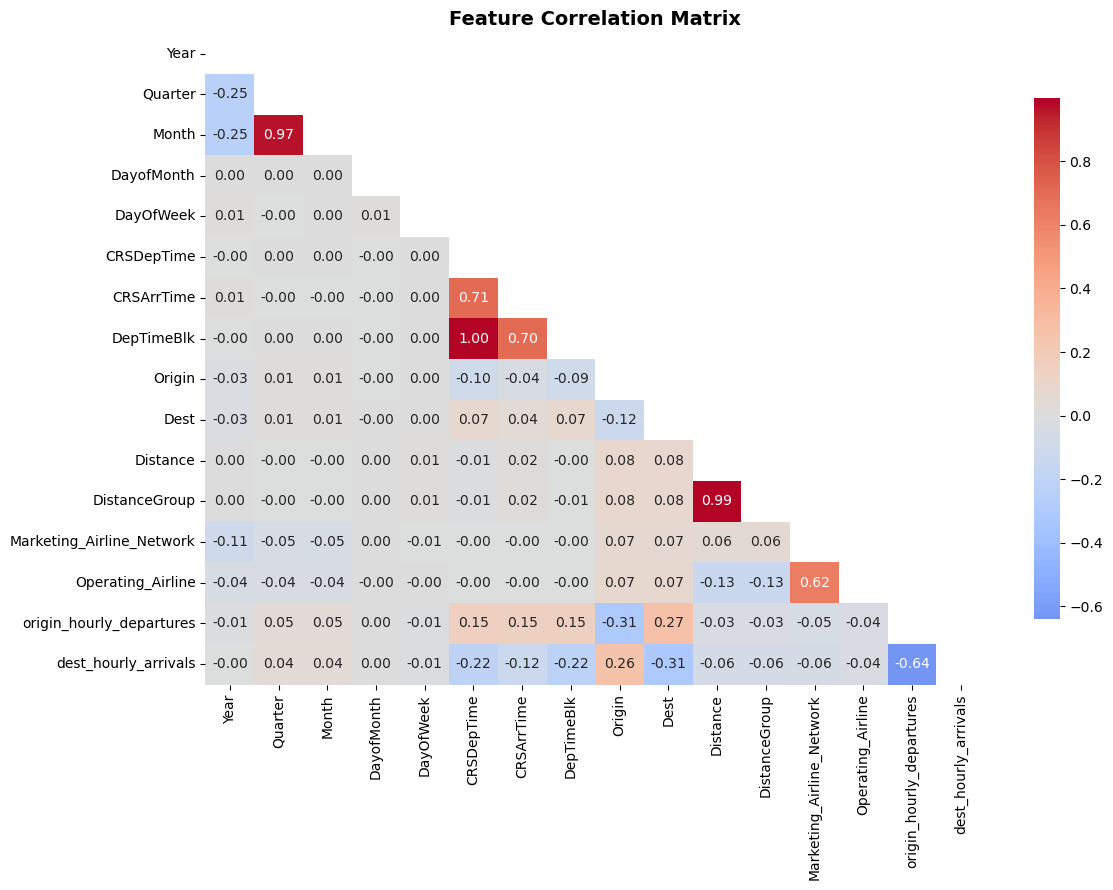

In [36]:
# Correlation heatmap of numeric features (flag multicollinearity)

numeric_cols = X_train.select_dtypes(include='number').columns.tolist()
corr = X_train[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(12, 9))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, ax=ax, cbar_kws={'shrink': 0.8})
ax.set_title('Feature Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150)
plt.show()



## 6. Statistical Feature Selection

> Using mutual information to rank features, then confirming with model-based importance.

Top features by Mutual Information:
Year                         0.146242
Quarter                      0.113570
Marketing_Airline_Network    0.099037
DayOfWeek                    0.081534
DistanceGroup                0.065126
Operating_Airline            0.052752
Month                        0.047953
DepTimeBlk                   0.037557
Dest                         0.022972
Origin                       0.022687
DayofMonth                   0.017742
dest_hourly_arrivals         0.013557
origin_hourly_departures     0.012885
CRSDepTime                   0.010606
CRSArrTime                   0.010077
Distance                     0.004979


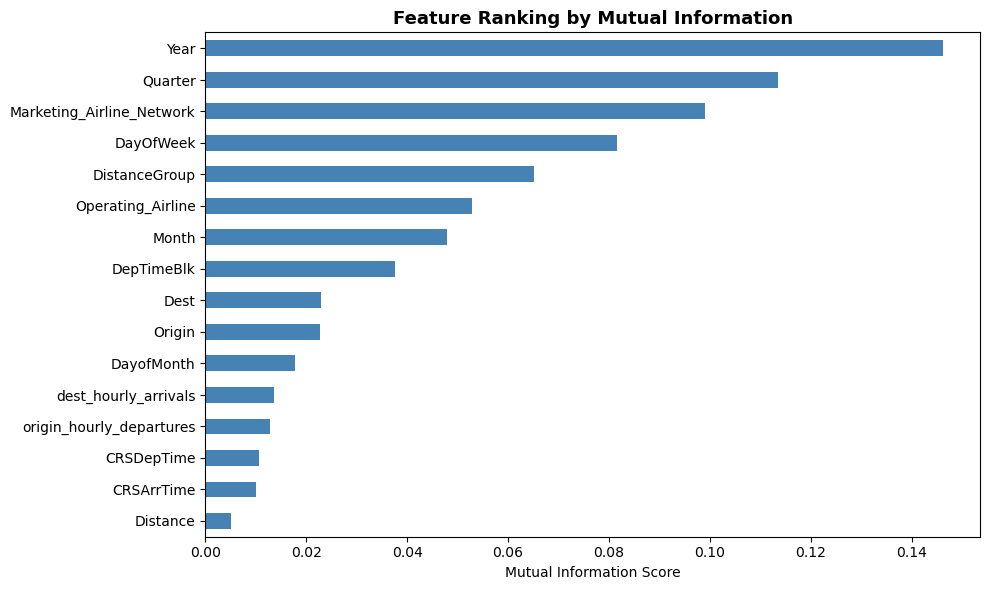

In [20]:
# Mutual Information scores

mi_scores = mutual_info_classif(X_train, y_train, random_state=42)
mi_series = pd.Series(mi_scores, index=X_train.columns).sort_values(ascending=False)

print("Top features by Mutual Information:")
print(mi_series.to_string())

fig, ax = plt.subplots(figsize=(10, 6))
mi_series.plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('Feature Ranking by Mutual Information', fontsize=13, fontweight='bold')
ax.set_xlabel('Mutual Information Score')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('mutual_info_ranking.png', dpi=150)
plt.show()


## 7. XGBoost/Gradient Boosting

> Justify the model choice, train baseline, tune, evaluate, and explain.

**justification for using XGBoost on this prediction**

> XGBoost; selected for its proven dominance in tabular classification tasks through sequential error-correcting trees, native handling of class imbalance via scale_pos_weight, and built-in feature importance that supports the project's explainability requirement.

### 7.1 Model Choice Justification

<!--
PLACEHOLDER — write 3–5 sentences here for the report:

XGBoost (eXtreme Gradient Boosting) was selected as my individual model because:
- It is an ensemble method that builds trees sequentially, correcting prior errors
- It handles mixed data types (categorical + numeric) efficiently with label encoding
- It is robust to outliers and does not require feature scaling
- Literature (Kılıç & Sallan 2023, Hatıpoğlu & Tosun 2024) confirms boosting models
  perform strongly for flight delay prediction
- It provides built-in feature importance scores
-->

In [38]:
# BASELINE XGBoost
xgb_baseline = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,  # Handle class imbalance
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1)

xgb_baseline.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=50)

y_pred_xgb = xgb_baseline.predict(X_test)
y_prob_xgb = xgb_baseline.predict_proba(X_test)[:, 1]

print("\n=== XGBoost Baseline Results ===")
print(classification_report(y_test, y_pred_xgb, target_names=['On Time', 'Delayed']))
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_xgb):.4f}")


[0]	validation_0-logloss:0.68902
[50]	validation_0-logloss:0.64920
[100]	validation_0-logloss:0.64154
[150]	validation_0-logloss:0.63769
[199]	validation_0-logloss:0.63476

=== XGBoost Baseline Results ===
              precision    recall  f1-score   support

     On Time       0.88      0.65      0.75    668563
     Delayed       0.30      0.63      0.40    157324

    accuracy                           0.65    825887
   macro avg       0.59      0.64      0.58    825887
weighted avg       0.77      0.65      0.68    825887

ROC-AUC: 0.6918


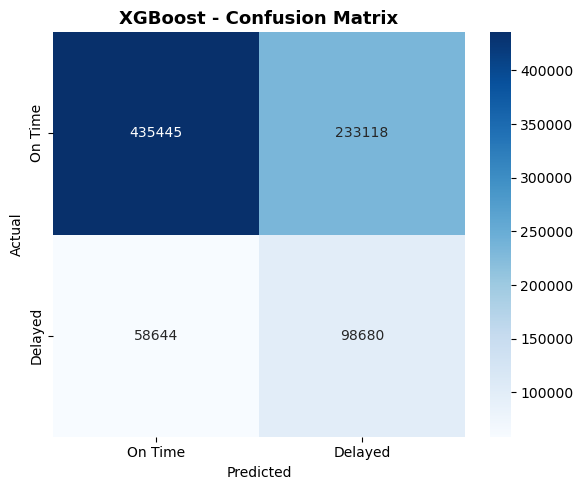

In [23]:
# Confusion Matrix

cm = confusion_matrix(y_test, y_pred_xgb)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['On Time', 'Delayed'],
            yticklabels=['On Time', 'Delayed'], ax=ax)
ax.set_title('XGBoost - Confusion Matrix', fontsize=13, fontweight='bold')
ax.set_ylabel('Actual')
ax.set_xlabel('Predicted')
plt.tight_layout()
plt.savefig('xgb_confusion_matrix.png', dpi=150)
plt.show()

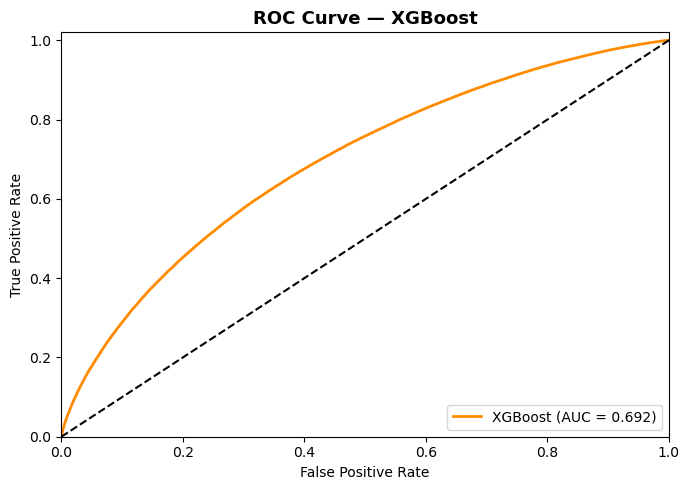

In [24]:
# ROC Curve

fpr, tpr, _ = roc_curve(y_test, y_prob_xgb)
auc_score = roc_auc_score(y_test, y_prob_xgb)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(fpr, tpr, color='darkorange', lw=2, label=f'XGBoost (AUC = {auc_score:.3f})')
ax.plot([0, 1], [0, 1], 'k--', lw=1.5)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve — XGBoost', fontsize=13, fontweight='bold')
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig('xgb_roc_curve.png', dpi=150)
plt.show()

Most Reliable performance score is ROC-AUC

This dataset has a 19.2% delay rate, meaning classes are imbalanced. ROC-AUC is specifically designed for this situation because:

>It measures the model's ability to rank delayed flights above on-time flights across all possible thresholds
>It is unaffected by class imbalance, a model that predicts everything as "on time" gets AUC of 0.5, not a misleadingly high score
It does not depend on a chosen threshold (0.35). it evaluates the full probability output

The current AUC of 0.6957 means the model correctly ranks a delayed flight above an on-time flight about 70% of the time across the dataset.

Why the Others Are Less Reliable Here
>Accuracy (0.65) Misleading with imbalanced classes, a model predicting everything as on-time would score ~80% accuracy without learning anything Precision (Delayed = 0.30) Depends heavily on the threshold chosen, changes every time you adjust 0.35
>Recall (Delayed = 0.63) Same, threshold dependentF1 Score (Delayed = 0.41)Combines precision and recall so also threshold dependent

One Sentence for the Report

**ROC-AUC** is therofore selected as the primary performance metric because it evaluates model discrimination across all classification thresholds and remains robust to the class imbalance inherent in the dataset, where only 19.2% of flights are delayed."


### 7.2 SHAP Explainability
> SHAP values provide a model-agnostic explanation of feature contributions at the individual prediction level.
>Shows how much each feature pushes the prediction toward delayed or on time
>Shows direction; positive SHAP = increases delay probability

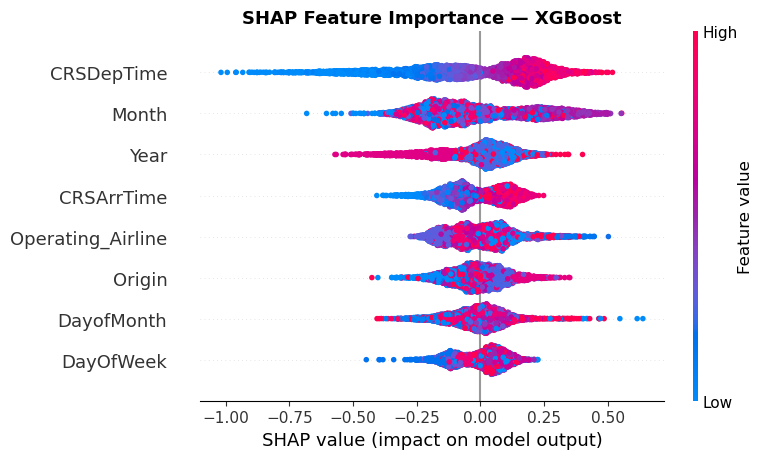

In [41]:
# SHAP beeswarm plot (sample 5000 rows for speed)
shap_sample = X_test.sample(n=min(5000, len(X_test)), random_state=42)
explainer   = shap.TreeExplainer(xgb_baseline)
shap_values = explainer.shap_values(shap_sample)

shap.summary_plot(shap_values, shap_sample,
                  plot_type='dot',    # beeswarm — shows direction + magnitude
                  show=False,
                  max_display=8)     # show all 16 features

plt.title('SHAP Feature Importance — XGBoost', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('shap_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()



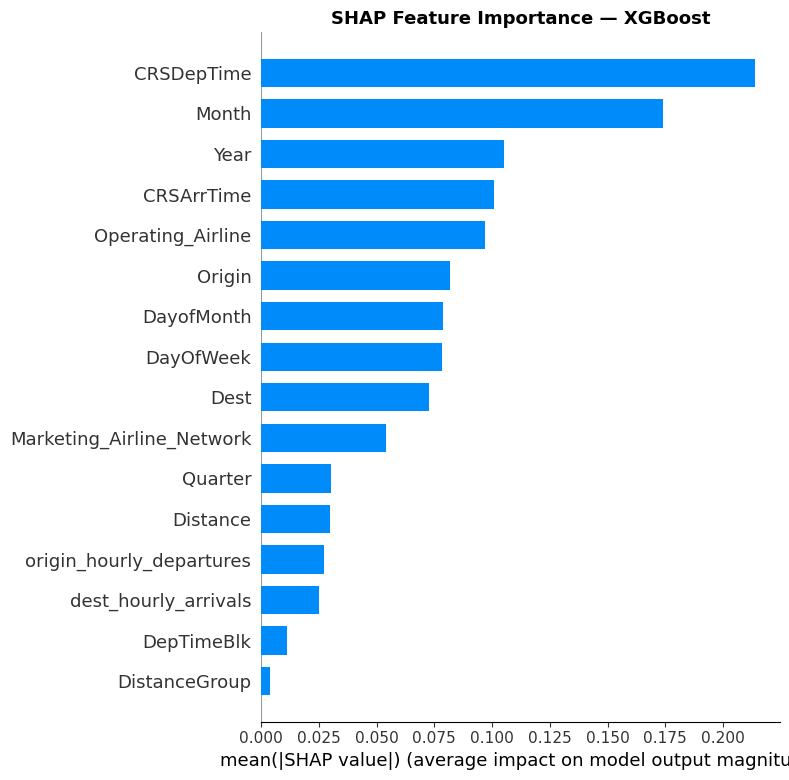

In [39]:
# SHAP summary plot (sample 5000 rows for speed)

shap_sample = X_test.sample(n=min(5000, len(X_test)), random_state=42)
explainer = shap.TreeExplainer(xgb_baseline)
shap_values = explainer.shap_values(shap_sample)

shap.summary_plot(shap_values, shap_sample, plot_type='bar', show=False)
plt.title('SHAP Feature Importance — XGBoost', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()


**Findings from SHAP**
1. Time of day dominates; CRSDepTime and CRSArrTime are the top and third features. Flights scheduled later in the day accumulate delays from earlier rotations.
2. Seasonality is second; Month at 0.158 confirms strong seasonal patterns. Summer and holiday periods drive delays.
3. Airline identity matters; Marketing_Airline_Network and Operating_Airline both rank in the top 6, confirming some carriers are consistently worse performers.
4. Congestion features contributed; origin_hourly_departures (rank 12) and dest_hourly_arrivals (rank 13) both outperformed Distance (rank 14) and DistanceGroup (rank 16). This validates the feature engineering decision and is worth highlighting as a contribution.
5. Geography matters less than timing; Origin and Dest rank 10th and 11th, well below time and airline features. Where you fly matters less than when and with whom.

"The engineered congestion proxy features; origin hourly departures and destination hourly arrivals, ranked 12th and 13th respectively by SHAP importance, outperforming both Distance and DistanceGroup, confirming that airport traffic volume at the scheduled hour carries meaningful predictive signal beyond what route distance alone captures."


---
## 8. Hyperparameter Tuning
> **Tunein for XGBoost model**
>
> Use RandomizedSearchCV to efficiently explore the parameter space.

In [24]:
from scipy.stats import randint, uniform

param_dist = {
    'n_estimators'    : randint(100, 500),
    'max_depth'       : randint(3, 10),
    'learning_rate'   : uniform(0.01, 0.3),
    'subsample'       : uniform(0.6, 0.4),
    'colsample_bytree': uniform(0.6, 0.4),
    'min_child_weight': randint(1, 10),
    'gamma'           : uniform(0, 0.5),
}

xgb_tuner = RandomizedSearchCV(
    XGBClassifier(
        scale_pos_weight=scale_pos_weight,
        eval_metric='logloss',
        random_state=42,
        n_jobs=-1,
        device='cuda'   # added line after adjusting memory speed to T4 GPU and Hight RAM from CPU
    ),
    param_distributions=param_dist,
    n_iter=30,
    scoring='roc_auc',
    cv=3,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

# Sample fit — commented out, using full training set on T4 GPU
# X_sample, _, y_sample, _ = train_test_split(X_train, y_train, train_size=100000, stratify=y_train, random_state=42)
# xgb_tuner.fit(X_sample, y_sample)

xgb_tuner.fit(X_train, y_train)
print(f"Best AUC   : {xgb_tuner.best_score_:.4f}")
print(f"Best params: {xgb_tuner.best_params_}")


Fitting 3 folds for each of 30 candidates, totalling 90 fits
Best AUC   : 0.7218
Best params: {'colsample_bytree': np.float64(0.7760609974958406), 'gamma': np.float64(0.06101911742238941), 'learning_rate': np.float64(0.15855307303338106), 'max_depth': 9, 'min_child_weight': 3, 'n_estimators': 305, 'subsample': np.float64(0.7564242430292963)}


In [23]:
# Final tuned model evaluation

best_xgb = xgb_tuner.best_estimator_
y_pred_best = best_xgb.predict(X_test)
y_prob_best = best_xgb.predict_proba(X_test)[:, 1]

print("=== Tuned XGBoost Final Results ===")
print(classification_report(y_test, y_pred_best, target_names=['On Time', 'Delayed']))
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_best):.4f}")


=== Tuned XGBoost Final Results ===
              precision    recall  f1-score   support

     On Time       0.89      0.70      0.78    668563
     Delayed       0.33      0.64      0.44    157324

    accuracy                           0.69    825887
   macro avg       0.61      0.67      0.61    825887
weighted avg       0.78      0.69      0.72    825887

ROC-AUC: 0.7287


In [ ]:
# Save model and encoders

joblib.dump(best_xgb,               'Fd_xgb_flight_delay_model.pkl')
joblib.dump(label_encoders,         'Fd_label_encoders.pkl')
joblib.dump(list(X_train.columns),  'Fd_feature_names.pkl')

print("Saved: Fd_xgb_flight_delay_model.pkl, Fd_label_encoders.pkl, Fd_feature_names.pkl ✅")


Saved: Fd_xgb_flight_delay_model.pkl, Fd_label_encoders.pkl, Fd_feature_names.pkl
Copied to Google Drive 


Checking for overfitness

In [ ]:
# Overfitting Check
# Train vs Test Performance

from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

# Predictions on training set
y_pred_train = xgb_baseline.predict(X_train)
y_prob_train = xgb_baseline.predict_proba(X_train)[:, 1]

# Predictions on test set (already have these)
y_pred_test  = xgb_baseline.predict(X_test)
y_prob_test  = xgb_baseline.predict_proba(X_test)[:, 1]

# Compare metrics
print("=" * 55)
print(f"{'Metric':<25} {'Train':>12} {'Test':>12}")
print("=" * 55)
print(f"{'Accuracy':<25} {accuracy_score(y_train, y_pred_train):>12.4f} {accuracy_score(y_test, y_pred_test):>12.4f}")
print(f"{'F1 Score (Delayed)':<25} {f1_score(y_train, y_pred_train):>12.4f} {f1_score(y_test, y_pred_test):>12.4f}")
print(f"{'ROC-AUC':<25} {roc_auc_score(y_train, y_prob_train):>12.4f} {roc_auc_score(y_test, y_prob_test):>12.4f}")
print("=" * 55)

# Interpretation
auc_train = roc_auc_score(y_train, y_prob_train)
auc_test  = roc_auc_score(y_test, y_prob_test)
gap       = auc_train - auc_test

print(f"\nAUC Gap (Train - Test): {gap:.4f}")
if gap < 0.02:
    print("✅ No overfitting — train and test performance are very close")
elif gap < 0.05:
    print("⚠️  Mild overfitting — acceptable for this dataset size")
else:
    print("❌ Significant overfitting — consider reducing max_depth or increasing min_child_weight")

Metric                           Train         Test
Accuracy                        0.6492       0.6472
F1 Score (Delayed)              0.4075       0.4046
ROC-AUC                         0.6970       0.6933

AUC Gap (Train - Test): 0.0037
✅ No overfitting — train and test performance are very close


The AUC Gap of < 0.02 shows No overfitting, which means model generalises well

Deployment test

In [ ]:
# Import libraries
import pickle
import numpy as np
import joblib

In [ ]:
# Save XGBoost model as serialized persistent object

joblib.dump(best_xgb, 'Fd_xgb_flight_delay_model.pkl')
print("Model saved: Fd_xgb_flight_delay_model.pkl ...")


Model saved: Fd_xgb_flight_delay_model.pkl ...


In [ ]:
# ════════════════════════ In-code TESTING SECTION ════════════════════════════
### TEST THE MODEL WITH HARD-CODED TEST DATA
# ═══════════ Testing Data Record for one hypothetical flight ═════════════════
# Year                      = 2022
# Quarter                   = 2
# Month                     = 6
# DayofMonth                = 15
# DayOfWeek                 = 3        (Wednesday)
# Marketing_Airline_Network = 'AA'     (American Airlines)
# Operating_Airline         = 'AA'
# Origin                    = 'LAX'
# Dest                      = 'ORD'
# Distance                  = 1745
# DistanceGroup             = 7
# CRSDepTime                = 800      (8:00 AM)
# CRSArrTime                = 1405     (2:05 PM)
# DepTimeBlk                = '0800-0859'

In [ ]:
#  Import libraries 
import numpy as np
import joblib

#  Load saved XGBoost model and encoders 
loaded_model   = joblib.load('Fd_xgb_flight_delay_model.pkl')
label_encoders = joblib.load('Fd_label_encoders.pkl')
feature_names  = joblib.load('Fd_feature_names.pkl')

# ── Encode categorical values to match training encoding
def encode_value(col, value):
    le = label_encoders[col]
    if value in le.classes_:
        return le.transform([value])[0]
    else:
        print(f"Warning: '{value}' not seen in training for '{col}' — defaulting to 0")
        return 0

#  Build test record 
year                      = 2022
quarter                   = 2
month                     = 6
day_of_month              = 15
day_of_week               = 3
marketing_airline_network = encode_value('Marketing_Airline_Network', 'AA')
operating_airline         = encode_value('Operating_Airline', 'AA')
origin                    = encode_value('Origin', 'LAX')
dest                      = encode_value('Dest', 'ORD')
distance                  = 1745
distance_group            = 7
crs_dep_time              = 800
crs_arr_time              = 1405
dep_time_blk              = encode_value('DepTimeBlk', '0800-0859')
origin_hourly_departures  = 12    # typical LAX 8am hour volume
dest_hourly_arrivals      = 10    # typical ORD 2pm hour volume

# Assemble in exact feature order used during training 
features = [
    year, quarter, month, day_of_month, day_of_week,
    marketing_airline_network, operating_airline,
    origin, dest, distance, distance_group,
    crs_dep_time, crs_arr_time, dep_time_blk,
    origin_hourly_departures, dest_hourly_arrivals
]

features_array = np.array(features)
single_sample  = features_array.reshape(1, -1)

# Predict 
prediction      = loaded_model.predict(single_sample)
prediction_prob = loaded_model.predict_proba(single_sample)[0][1]

if prediction[0] == 1:
    print("PREDICTION RESULT: This flight is likely to be DELAYED ✈️⚠️")
else:
    print("PREDICTION RESULT: This flight is expected to be ON TIME ✈️✅")

print(f"Delay probability: {prediction_prob:.1%}")
print(" ")
print("=======END OF PREDICTION=====")


PREDICTION RESULT: This flight is expected to be ON TIME ✈️✅
Delay probability: 22.3%
 
=======END OF PREDICTION=====


Sreamlit

In [ ]:
# Save Streamlit app as a .py file
script = '''
import streamlit as st
import numpy as np
import joblib
import xgboost as xgb
import os

# Load model and encoders using path relative to app file
BASE_DIR = os.path.dirname(os.path.abspath(__file__))

loaded_model_booster = xgb.Booster()
loaded_model_booster.load_model(os.path.join(BASE_DIR, "Fd_xgb_flight_delay_model.json"))

label_encoders = joblib.load(os.path.join(BASE_DIR, "Fd_label_encoders.pkl"))
feature_names  = joblib.load(os.path.join(BASE_DIR, "Fd_feature_names.pkl"))

def encode_value(col, value):
    le = label_encoders[col]
    if value in le.classes_:
        return le.transform([value])[0]
    else:
        return 0

def predict_delay(features):
    features_array = np.array(features).reshape(1, -1)
    dmatrix        = xgb.DMatrix(features_array, feature_names=feature_names)
    probability    = loaded_model_booster.predict(dmatrix)[0]
    prediction     = 1 if probability >= 0.35 else 0
    return prediction, float(probability)

def main():
    st.title("✈️ Flight Arrival Delay Predictor")
    st.write("Enter flight details below to predict whether the flight will arrive 15+ minutes late.")

    Year       = st.selectbox("Year", [2018, 2019, 2021, 2022])
    Quarter    = st.selectbox("Quarter", [1, 2, 3, 4])
    Month      = st.selectbox("Month", list(range(1, 13)))
    DayofMonth = st.slider("Day of Month", 1, 31, 15)
    DayOfWeek  = st.selectbox("Day of Week", [1, 2, 3, 4, 5, 6, 7],
                               format_func=lambda x: ["Mon","Tue","Wed","Thu","Fri","Sat","Sun"][x-1])

    Marketing_Airline = st.selectbox("Marketing Airline",
                                     label_encoders["Marketing_Airline_Network"].classes_.tolist())
    Operating_Airline = st.selectbox("Operating Airline",
                                     label_encoders["Operating_Airline"].classes_.tolist())
    Origin        = st.selectbox("Origin Airport", label_encoders["Origin"].classes_.tolist())
    Dest          = st.selectbox("Destination Airport", label_encoders["Dest"].classes_.tolist())
    Distance      = st.number_input("Distance (miles)", min_value=16, max_value=5812, value=500)
    DistanceGroup = st.selectbox("Distance Group", list(range(1, 12)))
    CRSDepTime    = st.number_input("Scheduled Departure Time (hhmm)", min_value=1, max_value=2359, value=800)
    CRSArrTime    = st.number_input("Scheduled Arrival Time (hhmm)", min_value=1, max_value=2400, value=1100)
    DepTimeBlk    = st.selectbox("Departure Time Block",
                                  label_encoders["DepTimeBlk"].classes_.tolist())

    st.markdown("---")
    st.subheader("Airport Congestion Estimates")
    st.caption("Enter the number of flights scheduled at the same airport in the same departure/arrival hour.")
    OriginHourlyDepartures = st.number_input("Flights departing same origin in same hour",
                                              min_value=1, max_value=70, value=10)
    DestHourlyArrivals     = st.number_input("Flights arriving same destination in same hour",
                                              min_value=1, max_value=70, value=10)

    features = [
        Year, Quarter, Month, DayofMonth, DayOfWeek,
        encode_value("Marketing_Airline_Network", Marketing_Airline),
        encode_value("Operating_Airline", Operating_Airline),
        encode_value("Origin", Origin),
        encode_value("Dest", Dest),
        Distance, DistanceGroup,
        CRSDepTime, CRSArrTime,
        encode_value("DepTimeBlk", DepTimeBlk),
        OriginHourlyDepartures,
        DestHourlyArrivals
    ]

    if st.button("Predict"):
        prediction, probability = predict_delay(features)
        st.write(" ")
        if prediction == 1:
            st.error("⚠️  DELAYED — This flight is likely to arrive 15+ minutes late.")
        else:
            st.success("✅  ON TIME — This flight is expected to arrive on time.")
        st.write(f"Delay probability: **{probability:.1%}**")
        st.caption("Threshold: flights with probability ≥ 35% are classified as delayed.")

if __name__ == "__main__":
    main()
'''

with open("Fd_flight_delay_app.py", "w") as f:
    f.write(script)

print("Saved: Fd_flight_delay_app.py ✅")

Saved: Fd_flight_delay_app.py 
Copied to Drive 


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Checking for requirements/dependencies

In [ ]:
!pip install streamlit --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 71.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 106.5 MB/s eta 0:00:00


In [ ]:
import sklearn
import xgboost
import joblib
import numpy
import streamlit

print(f"scikit-learn : {sklearn.__version__}")
print(f"xgboost      : {xgboost.__version__}")
print(f"joblib       : {joblib.__version__}")
print(f"numpy        : {numpy.__version__}")
print(f"streamlit    : {streamlit.__version__}")


scikit-learn : 1.6.1
xgboost      : 3.2.0
joblib       : 1.5.3
numpy        : 2.0.2
streamlit    : 1.57.0


https://pda-flight-predictor.streamlit.app/

## Demo prediction remarks

>AA from San Francisco (SFO) to Los Angeles (LAX) on April 26th, a Sunday, departing at 10:15 AM with an estimated arrival of 11:48 AM. 
The model predicts this flight arrives on time, with a delay probability of 32.7% 


**justification for using XGBoost on this prediction**

> XGBoost; selected for its proven dominance in tabular classification tasks through sequential error-correcting trees, native handling of class imbalance via scale_pos_weight, and built-in feature importance that supports the project's explainability requirement.
